In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/madhurpant/world-economic-data/unemployment.csv
/kaggle/input/datasets/madhurpant/world-economic-data/richest_countries.csv
/kaggle/input/datasets/madhurpant/world-economic-data/tourism.csv
/kaggle/input/datasets/madhurpant/world-economic-data/corruption.csv
/kaggle/input/datasets/madhurpant/world-economic-data/cost_of_living.csv


# 1. Project Overview & Business Objective

### Business Problem
Businesses, investors, and consultants often face difficulty selecting
countries for expansion or investment due to fragmented economic data.

This project combines multiple economic indicators into a unified
AI-powered scoring and insight system to support data-driven decisions.

### Target Users
- Startups planning international expansion
- Investors screening global markets
- Consultants preparing country risk reports

### Key Output
- Opportunity Score (0–100)
- Country clusters (market types)
- Automated business insights

# 2. Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
unemployment = pd.read_csv("/kaggle/input/datasets/madhurpant/world-economic-data/unemployment.csv")
gdp = pd.read_csv("/kaggle/input/datasets/madhurpant/world-economic-data/richest_countries.csv")
cost = pd.read_csv("/kaggle/input/datasets/madhurpant/world-economic-data/cost_of_living.csv")
corruption = pd.read_csv("/kaggle/input/datasets/madhurpant/world-economic-data/corruption.csv")
tourism = pd.read_csv("/kaggle/input/datasets/madhurpant/world-economic-data/tourism.csv")

# Quick sanity check
for df_name, df in {
    "Unemployment": unemployment,
    "GDP": gdp,
    "Cost": cost,
    "Corruption": corruption,
    "Tourism": tourism
}.items():
    print(df_name, df.shape)

Unemployment (64, 2)
GDP (50, 2)
Cost (107, 4)
Corruption (110, 3)
Tourism (41, 5)


# 3. Data Cleaning & Country Matching

In [3]:
# Standardize column names
unemployment.columns = ["country", "unemployment_rate"]
gdp.columns = ["country", "gdp_per_capita"]

# Merge datasets step-by-step
df = gdp.merge(unemployment, on="country", how="left")
df = df.merge(cost, on="country", how="left")
df = df.merge(corruption[["country", "corruption_index"]], on="country", how="left")
df = df.merge(
    tourism[["country", "receipts_in_billions", "percentage_of_gdp"]],
    on="country",
    how="left"
)

# Remove duplicates & inspect missing values
df = df.drop_duplicates()
df.isna().mean().sort_values(ascending=False)

receipts_in_billions      0.54
percentage_of_gdp         0.54
unemployment_rate         0.42
corruption_index          0.32
cost_index                0.16
purchasing_power_index    0.16
monthly_income            0.16
country                   0.00
gdp_per_capita            0.00
dtype: float64

# 4. Feature Engineering (CORE VALUE!)

In [4]:
# Affordability Index
df["affordability_index"] = df["gdp_per_capita"] / df["cost_index"]

# Labor Stress Indicator
df["labor_stress"] = df["unemployment_rate"] * df["cost_index"]

# Tourism dependency risk
df["tourism_dependency"] = df["percentage_of_gdp"].fillna(0)

# Replace extreme NaNs conservatively
df = df.fillna(df.median(numeric_only=True))

df.head()

,country,gdp_per_capita,unemployment_rate,cost_index,monthly_income,purchasing_power_index,corruption_index,receipts_in_billions,percentage_of_gdp,affordability_index,labor_stress,tourism_dependency
0,Luxembourg,134754,5.2,113.1,6759.0,101.8,19.0,4.45,5.1,1191.458886,588.12,5.1
1,Singapore,116486,3.6,75.0,5334.0,121.1,15.0,10.93,1.4,1553.146667,270.00,0.0
2,Ireland,106456,6.6,119.8,6210.0,88.3,26.0,10.93,1.4,888.614357,790.68,0.0
3,Qatar,93521,0.3,71.4,4760.0,113.6,37.0,14.32,8.0,1309.817927,21.42,8.0
4,Bermuda,85192,7.0,157.6,9712.0,105.0,26.5,0.09,1.3,540.558376,1103.20,1.3


# 5. Exploratory Data Analysis (EDA)

## 5.1 GDP vs Cost of Living

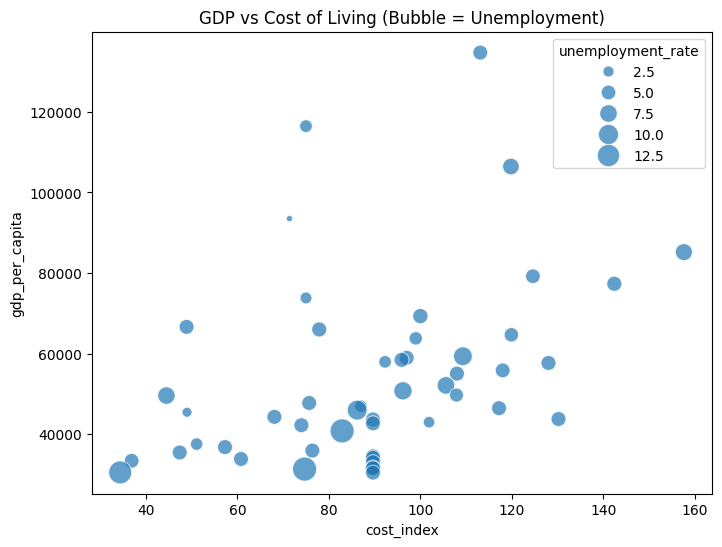

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="cost_index",
    y="gdp_per_capita",
    size="unemployment_rate",
    sizes=(20, 300),
    alpha=0.7
)
plt.title("GDP vs Cost of Living (Bubble = Unemployment)")
plt.show()


## 5.2 Corruption vs Opportunity Signals

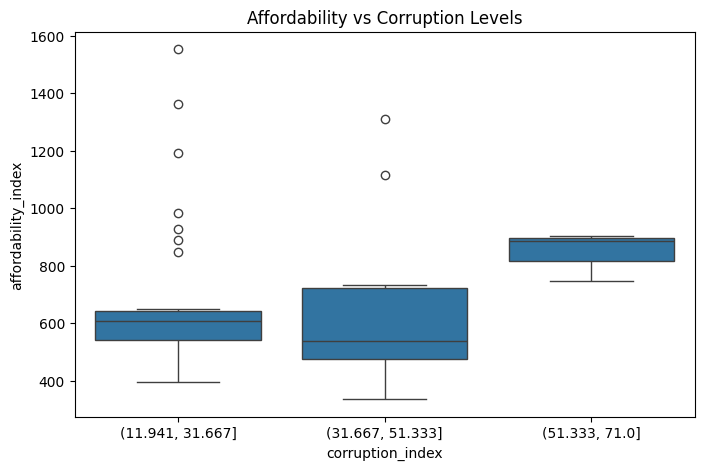

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(x=pd.cut(df["corruption_index"], 3), y=df["affordability_index"])
plt.title("Affordability vs Corruption Levels")
plt.show()

# 6. Economic Opportunity Scoring Model (AI Layer)

In [7]:
from sklearn.preprocessing import MinMaxScaler

score_features = [
    "gdp_per_capita",
    "purchasing_power_index",
    "receipts_in_billions",
    "unemployment_rate",
    "corruption_index"
]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[score_features])

score_df = pd.DataFrame(scaled, columns=score_features)

# Opportunity Score formula
df["opportunity_score"] = (
    score_df["gdp_per_capita"] * 0.30 +
    score_df["purchasing_power_index"] * 0.25 +
    score_df["receipts_in_billions"] * 0.15 -
    score_df["unemployment_rate"] * 0.15 -
    score_df["corruption_index"] * 0.15
) * 100

df[["country", "opportunity_score"]].sort_values(
    by="opportunity_score", ascending=False
).head(10)

,country,opportunity_score
1,Singapore,47.503601
0,Luxembourg,43.101540
3,Qatar,37.060736
8,United States,34.086604
2,Ireland,28.816099
10,Hong Kong,26.201790
5,Norway,26.168862
4,Bermuda,25.270177
16,Germany,25.094909
6,Switzerland,24.870057


# 7. Country Clustering (Market Typing)

In [8]:
from sklearn.cluster import KMeans

cluster_features = df[
    ["opportunity_score", "tourism_dependency", "corruption_index"]
]

kmeans = KMeans(n_clusters=4, random_state=42)
df["market_cluster"] = kmeans.fit_predict(cluster_features)

df["market_cluster"].value_counts()

market_cluster
0    25
2    14
3     7
1     4
Name: count, dtype: int64

## 7.1 Visualize Clusters

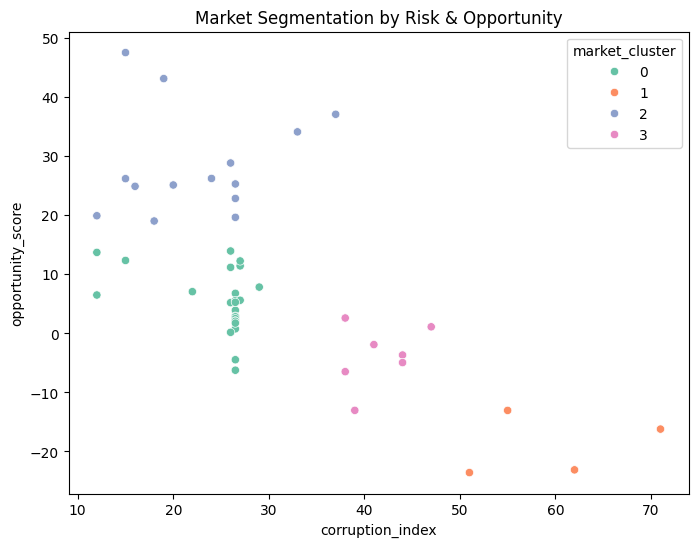

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="corruption_index",
    y="opportunity_score",
    hue="market_cluster",
    palette="Set2"
)
plt.title("Market Segmentation by Risk & Opportunity")
plt.show()

# 8. Automated Insight Generator (WOW Feature)

In [10]:
def generate_insight(row):
    if row.opportunity_score > 70 and row.corruption_index < 40:
        return "High opportunity, low risk — strong candidate for expansion."
    elif row.opportunity_score > 60 and row.corruption_index >= 40:
        return "Attractive market but requires strong compliance controls."
    elif row.tourism_dependency > 5:
        return "Tourism-dependent economy — vulnerable to external shocks."
    else:
        return "Moderate opportunity with balanced risk."

df["auto_insight"] = df.apply(generate_insight, axis=1)

df[["country", "opportunity_score", "auto_insight"]].head(10)

,country,opportunity_score,auto_insight
0,Luxembourg,43.101540,Tourism-dependent economy — vulnerable to exte...
1,Singapore,47.503601,Moderate opportunity with balanced risk.
2,Ireland,28.816099,Moderate opportunity with balanced risk.
3,Qatar,37.060736,Tourism-dependent economy — vulnerable to exte...
4,Bermuda,25.270177,Moderate opportunity with balanced risk.
5,Norway,26.168862,Moderate opportunity with balanced risk.
6,Switzerland,24.870057,Moderate opportunity with balanced risk.
7,Macao,22.818364,Tourism-dependent economy — vulnerable to exte...
8,United States,34.086604,Moderate opportunity with balanced risk.
9,Brunei,19.618659,Moderate opportunity with balanced risk.


## 8.5 Assumptions & Limitations

While this dashboard provides data-driven economic insights, it is important
to highlight the assumptions and limitations underlying the analysis.
These considerations help ensure responsible interpretation and usage
of the results.

### Key Assumptions

- **Country-level aggregation**  
  The analysis assumes that national-level economic indicators are
  sufficiently representative of overall market conditions.  
  Sub-national disparities (e.g., regional inequality) are not explicitly modeled.

- **Static snapshot of data**  
  The dataset represents a point-in-time view rather than real-time or
  continuously updated economic conditions.  
  Sudden shocks (political events, crises, pandemics) are not captured.

- **Linear contribution of indicators**  
  The Opportunity Score assumes that each economic factor contributes
  linearly and independently to overall opportunity, using weighted scaling.

- **Equal accessibility of markets**  
  The model assumes comparable access to markets across countries,
  without explicitly accounting for regulatory barriers, trade sanctions,
  or geopolitical restrictions.

---

### Known Limitations

- **No causal inference**  
  The analysis identifies patterns and correlations but does not establish
  causal relationships between economic indicators.

- **Limited qualitative context**  
  Factors such as political stability, ease of doing business, cultural barriers,
  and industry-specific conditions are not directly incorporated.

- **Tourism data variability**  
  Tourism-related metrics may fluctuate significantly year-to-year and
  can overstate opportunity in countries highly dependent on tourism revenue.

- **Corruption index interpretation**  
  The corruption indicator reflects perception-based measurements,
  which may not fully capture on-the-ground operational realities.

---

### Intended Use

This dashboard is designed as a **decision-support tool**, not a definitive
investment or expansion recommendation.  
Final decisions should incorporate industry knowledge, expert judgment,
and up-to-date local intelligence.

Future iterations may enhance accuracy through:
- Time-series modeling
- Industry-specific scoring
- Integration of real-time economic indicators

# 9. Business Recommendations & Final Output

In [11]:
top_markets = df.sort_values("opportunity_score", ascending=False).head(15)

top_markets[
    ["country", "opportunity_score", "market_cluster", "auto_insight"]
]

,country,opportunity_score,market_cluster,auto_insight
1,Singapore,47.503601,2,Moderate opportunity with balanced risk.
0,Luxembourg,43.101540,2,Tourism-dependent economy — vulnerable to exte...
3,Qatar,37.060736,2,Tourism-dependent economy — vulnerable to exte...
8,United States,34.086604,2,Moderate opportunity with balanced risk.
2,Ireland,28.816099,2,Moderate opportunity with balanced risk.
10,Hong Kong,26.201790,2,Tourism-dependent economy — vulnerable to exte...
5,Norway,26.168862,2,Moderate opportunity with balanced risk.
4,Bermuda,25.270177,2,Moderate opportunity with balanced risk.
16,Germany,25.094909,2,Moderate opportunity with balanced risk.
6,Switzerland,24.870057,2,Moderate opportunity with balanced risk.


### Key Takeaways
- Not all high-GDP countries offer real affordability
- Tourism-heavy economies score high but carry shock risk
- Medium-income countries with low cost present untapped potential